# Notebook Eksperimen K-Means 

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score  
from sklearn.decomposition import PCA 

from yellowbrick.cluster import KElbowVisualizer


np.random.seed(10122097)

In [2]:
train = pd.read_csv('../datasets/train.csv', parse_dates=['date']).drop(columns='id')
transactions = pd.read_csv('../datasets/transactions.csv', parse_dates=['date'])
df_full_stats = pd.read_csv('descriptive_stats_all_combinations.csv')
stores = pd.read_csv('../datasets/stores.csv')


In [3]:
df_full_stats

,store_nbr,family,n_days,mean,median,std,min,max,skewness,kurtosis,cv,adi,cv2,category
0,1,AUTOMOTIVE,1463,3.251188,3.0000,2.758785,0.0,19.000,1.394908,2.944256,0.848547,1.151059,0.494303,Erratic
1,1,BABY CARE,0,0.000000,0.0000,0.000000,0.0,0.000,NaN,NaN,0.000000,NaN,NaN,No Sales
2,1,BEAUTY,1430,2.408551,2.0000,1.898386,0.0,12.000,1.012293,1.407079,0.788186,1.177622,0.376704,Smooth
3,1,BEVERAGES,1678,1587.748812,1674.0000,726.654208,0.0,5051.000,0.176872,-0.721302,0.457663,1.003576,0.205146,Smooth
4,1,BOOKS,127,0.125297,0.0000,0.536419,0.0,8.000,6.492349,58.386677,4.281179,13.259843,0.457672,Intermittent
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1777,9,POULTRY,1679,483.880389,454.7850,164.129266,0.0,2198.853,1.342712,7.354173,0.339194,1.002978,0.111742,Smooth
1778,9,PREPARED FOODS,1679,88.762428,82.1865,35.037132,0.0,311.147,0.923715,1.572763,0.394729,1.002978,0.152379,Smooth
1779,9,PRODUCE,1016,969.134497,1122.1520,880.186206,0.0,4059.907,0.235316,-1.115796,0.908219,1.657480,0.100985,Intermittent
1780,9,SCHOOL AND OFFICE SUPPLIES,901,6.051069,1.0000,22.283794,0.0,326.000,7.911502,75.157282,3.682621,1.869034,6.791027,Lumpy


In [4]:
transactions

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922
...,...,...,...
83483,2017-08-15,50,2804
83484,2017-08-15,51,1573
83485,2017-08-15,52,2255
83486,2017-08-15,53,932


In [5]:
train

,date,store_nbr,family,sales,onpromotion
0,2013-01-01,1,AUTOMOTIVE,0.000,0
1,2013-01-01,1,BABY CARE,0.000,0
2,2013-01-01,1,BEAUTY,0.000,0
3,2013-01-01,1,BEVERAGES,0.000,0
4,2013-01-01,1,BOOKS,0.000,0
...,...,...,...,...,...
3000883,2017-08-15,9,POULTRY,438.133,0
3000884,2017-08-15,9,PREPARED FOODS,154.553,1
3000885,2017-08-15,9,PRODUCE,2419.729,148
3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8


In [6]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

## Melakukan K-Means Dengan Fitur Univariat

In [7]:
store_univariate_features = train.groupby('store_nbr').agg(
    total_sales = ('sales', 'sum')
).reset_index()

store_univariate_features.head()

,store_nbr,total_sales
0,1,1.414501e+07
1,2,2.155739e+07
2,3,5.048191e+07
3,4,1.890970e+07
4,5,1.559240e+07


In [8]:
store_univariate_features = store_univariate_features.merge(stores[['store_nbr','type']], on='store_nbr')

In [9]:
scaler = StandardScaler()

In [10]:
X_univariate_scaled = scaler.fit_transform(store_univariate_features[['total_sales']])

store_univariate_features['kmeans_cluster'] = kmeans.fit_predict(X_univariate_scaled)

<Axes: title={'center': 'K-Means Univariate'}, xlabel='kmeans_cluster'>

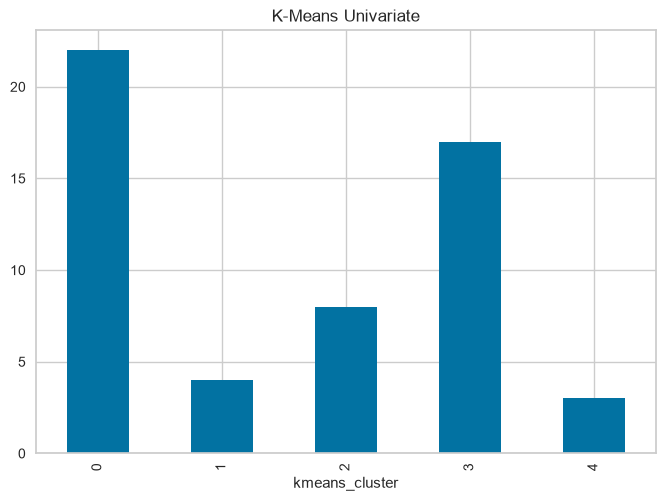

In [11]:
store_univariate_features['kmeans_cluster'].value_counts().sort_index().plot(kind='bar',title='K-Means Univariate')

In [12]:
pd.crosstab(store_univariate_features['type'], store_univariate_features['kmeans_cluster'])

kmeans_cluster,0,1,2,3,4
type,,,,,
A,1,3,2,0,3
B,3,0,2,3,0
C,12,0,0,3,0
D,5,1,4,8,0
E,1,0,0,3,0


In [13]:
ari_univariate = adjusted_rand_score(store_univariate_features['type'], store_univariate_features['kmeans_cluster'])
nmi_univariate = normalized_mutual_info_score(store_univariate_features['type'], store_univariate_features['kmeans_cluster'])
print(f"\nAdjusted Rand Index: {ari_univariate:.4f}")
print(f"Normalized Mutual Info: {nmi_univariate:.4f}")


Adjusted Rand Index: 0.1368
Normalized Mutual Info: 0.2815


C:\Users\fikra\AppData\Local\Temp\ipykernel_19864\2952346602.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


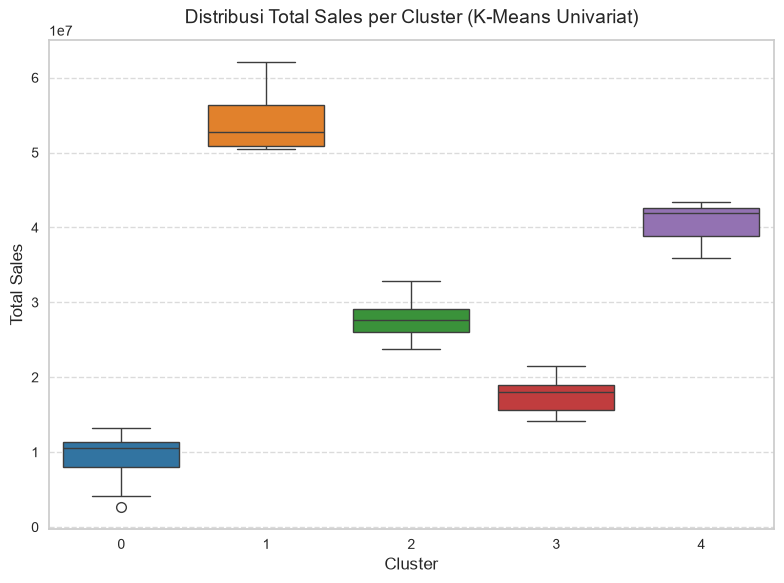

In [14]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=store_univariate_features,
    x='kmeans_cluster',
    y='total_sales',
    palette='tab10'
)
plt.title('Distribusi Total Sales per Cluster (K-Means Univariat)', fontsize=14, pad=12)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Melakukan K-Means Dengan Fitur Sederhana  
Hanya dengan fitur-fitur statistika seperti total penjualan, rerata, dan standar deviasi dari setiap toko

In [15]:
# Melakukan aggregasi data terlebih dahulu 
store_features = train.groupby('store_nbr').agg(
    total_sales = ('sales', 'sum'),
    mean_daily_sales = ('sales', 'mean'),
    std_daily_sales = ('sales', 'std'),
).reset_index()

store_features.head()

,store_nbr,total_sales,mean_daily_sales,std_daily_sales
0,1,1.414501e+07,254.534889,596.827146
1,2,2.155739e+07,387.918172,1079.560490
2,3,5.048191e+07,908.405495,2146.185033
3,4,1.890970e+07,340.273886,801.128208
4,5,1.559240e+07,280.580231,652.588149


In [16]:
store_features = store_features.merge(stores[['store_nbr','type']], on='store_nbr')

feature_cols = ['total_sales', 'mean_daily_sales', 'std_daily_sales']

In [17]:
X_scaled = scaler.fit_transform(store_features[feature_cols])

store_features['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

<Axes: title={'center': 'K-Means With Simple Features'}, xlabel='kmeans_cluster'>

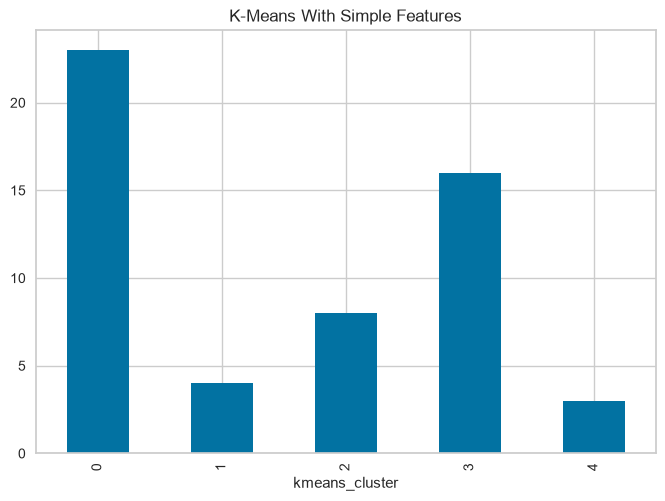

In [18]:
store_features['kmeans_cluster'].value_counts().sort_index().plot(kind='bar',title='K-Means With Simple Features')

In [19]:
pd.crosstab(store_features['type'], store_features['kmeans_cluster'])

kmeans_cluster,0,1,2,3,4
type,,,,,
A,1,3,2,0,3
B,2,0,2,4,0
C,13,0,0,2,0
D,6,1,4,7,0
E,1,0,0,3,0


In [20]:
ari = adjusted_rand_score(store_features['type'], store_features['kmeans_cluster'])
nmi = normalized_mutual_info_score(store_features['type'], store_features['kmeans_cluster'])
print(f"\nAdjusted Rand Index: {ari:.4f}")
print(f"Normalized Mutual Info: {nmi:.4f}")


Adjusted Rand Index: 0.1637
Normalized Mutual Info: 0.2993


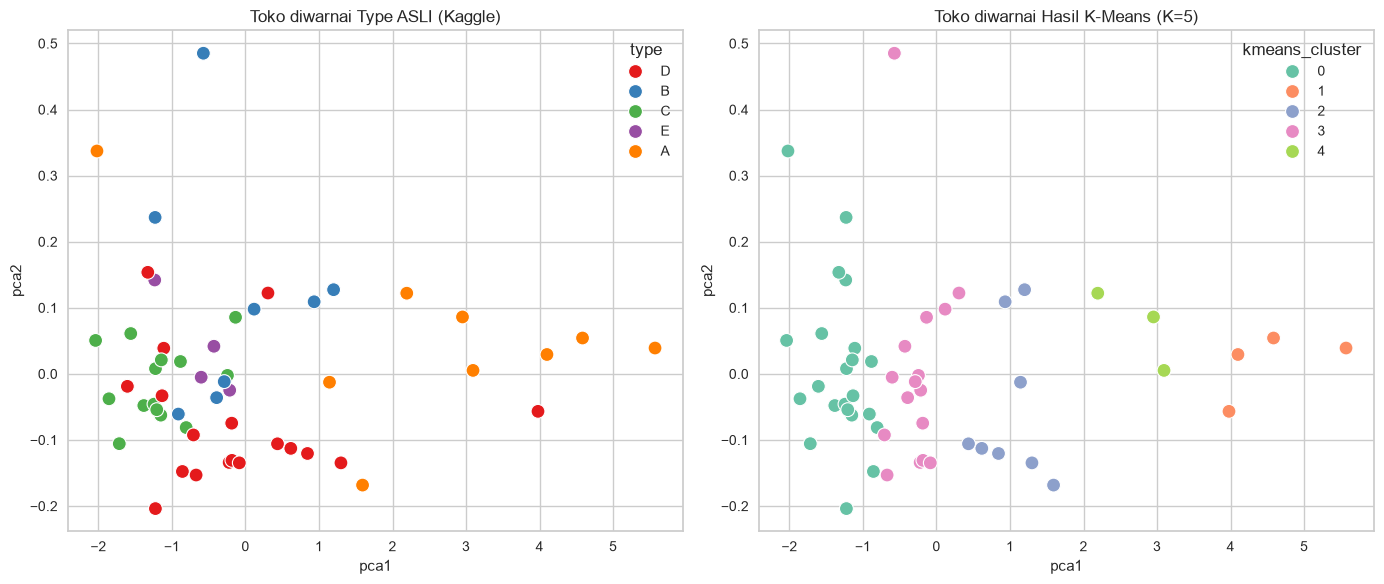

In [21]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
store_features['pca1'], store_features['pca2'] = X_pca[:,0], X_pca[:,1]

fig, axes = plt.subplots(1, 2, figsize=(14,6))
sns.scatterplot(data=store_features, x='pca1', y='pca2', hue='type', ax=axes[0], s=100, palette='Set1')
axes[0].set_title('Toko diwarnai Type ASLI (Kaggle)')
sns.scatterplot(data=store_features, x='pca1', y='pca2', hue='kmeans_cluster', ax=axes[1], s=100, palette='Set2')
axes[1].set_title('Toko diwarnai Hasil K-Means (K=5)')
plt.tight_layout()
plt.show()

## Melakukan K-Means Dengan Fitur Yang Lebih Advanced  
Pada K-Means kali ini akan digunakan fitur statistika yang lebih advanced seperti ADI dan CV^2 dan akan dibandingkan hasilnya seperti apa 

In [22]:
store_advanced_features = store_features.copy(['total_sales', 'mean_daily_sales', 'std_daily_sales']).drop(columns=['kmeans_cluster', 'pca1', 'pca2'])
store_advanced_features['cv'] = store_advanced_features['std_daily_sales'] / store_advanced_features['mean_daily_sales']

avg_trans = transactions.groupby('store_nbr')['transactions'].mean().reset_index()
avg_trans.columns = ['store_nbr', 'avg_transactions']
store_advanced_features = store_advanced_features.merge(avg_trans, on='store_nbr')

In [23]:
demand_char = df_full_stats.groupby('store_nbr')[['adi','cv2']].mean().reset_index()
demand_char.columns = ['store_nbr','avg_adi','avg_cv2']
store_advanced_features = store_advanced_features.merge(demand_char, on='store_nbr')

In [24]:
store_advanced_features.head()

,store_nbr,total_sales,mean_daily_sales,std_daily_sales,type,cv,avg_transactions,avg_adi,avg_cv2
0,1,1.414501e+07,254.534889,596.827146,D,2.344775,1523.844272,1.894112,0.578353
1,2,2.155739e+07,387.918172,1079.560490,D,2.782959,1920.036374,2.625532,0.412844
2,3,5.048191e+07,908.405495,2146.185033,D,2.362585,3201.879475,1.627286,0.301254
3,4,1.890970e+07,340.273886,801.128208,D,2.354363,1502.987470,4.963074,0.423413
4,5,1.559240e+07,280.580231,652.588149,D,2.325852,1400.045915,2.162497,0.659148


In [25]:
feature_cols = ['total_sales','mean_daily_sales','cv','avg_transactions','avg_adi','avg_cv2']
X_scaled_advanced = scaler.fit_transform(store_advanced_features[feature_cols])

store_advanced_features['kmeans_cluster'] = kmeans.fit_predict(X_scaled_advanced)

<Axes: title={'center': 'Advanced Feature K-Means'}, xlabel='kmeans_cluster'>

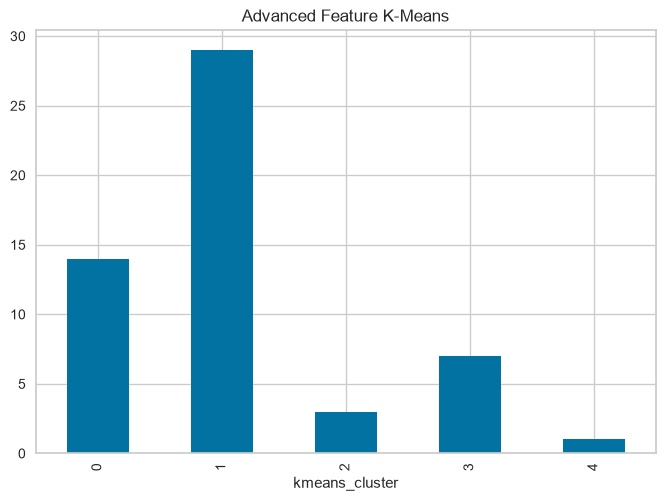

In [26]:
store_advanced_features['kmeans_cluster'].value_counts().sort_index().plot(kind='bar', title='Advanced Feature K-Means')

In [27]:
pd.crosstab(store_advanced_features['type'], store_advanced_features['kmeans_cluster'])

kmeans_cluster,0,1,2,3,4
type,,,,,
A,0,2,0,6,1
B,0,6,2,0,0
C,11,4,0,0,0
D,3,13,1,1,0
E,0,4,0,0,0


In [28]:
ari = adjusted_rand_score(store_advanced_features['type'], store_advanced_features['kmeans_cluster'])
nmi = normalized_mutual_info_score(store_advanced_features['type'], store_advanced_features['kmeans_cluster'])
print(f"\nAdjusted Rand Index: {ari:.4f}")
print(f"Normalized Mutual Info: {nmi:.4f}")


Adjusted Rand Index: 0.1986
Normalized Mutual Info: 0.3824


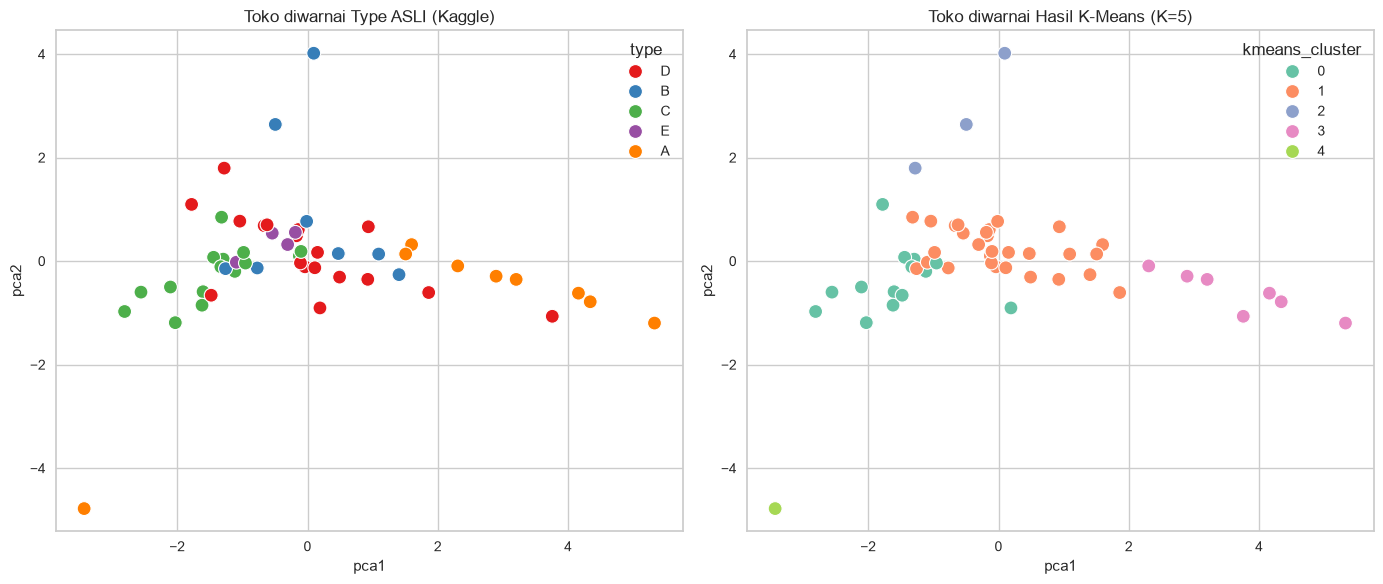

In [29]:
pca = PCA(n_components=2)
X_pca_advanced = pca.fit_transform(X_scaled_advanced)
store_advanced_features['pca1'], store_advanced_features['pca2'] = X_pca_advanced[:,0], X_pca_advanced[:,1]

fig, axes = plt.subplots(1, 2, figsize=(14,6))
sns.scatterplot(data=store_advanced_features, x='pca1', y='pca2', hue='type', ax=axes[0], s=100, palette='Set1')
axes[0].set_title('Toko diwarnai Type ASLI (Kaggle)')
sns.scatterplot(data=store_advanced_features, x='pca1', y='pca2', hue='kmeans_cluster', ax=axes[1], s=100, palette='Set2')
axes[1].set_title('Toko diwarnai Hasil K-Means (K=5)')
plt.tight_layout()
plt.show()

## Melihat Jumlah K Ideal Dengan Elbow Method

In [30]:
model = KMeans(random_state=42, n_init=10)

### Univariat

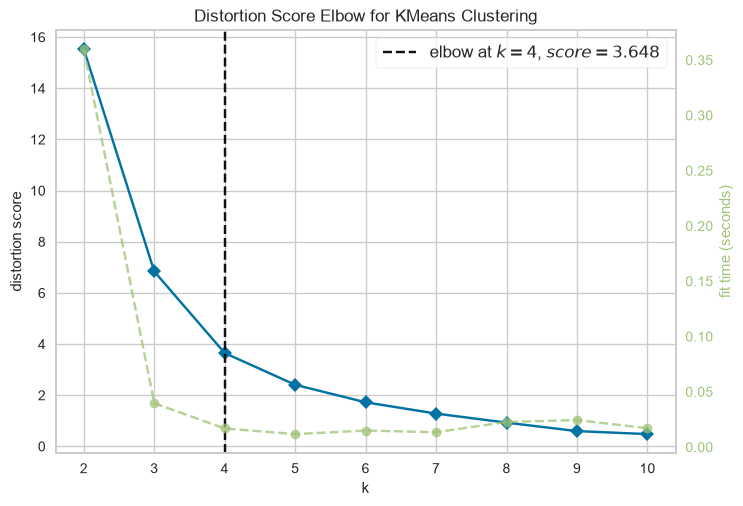

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [31]:
visualizer = KElbowVisualizer(model, k=(2, 11), force_model=True)
visualizer.fit(X_univariate_scaled)
visualizer.show()

### Untuk Yang Biasa

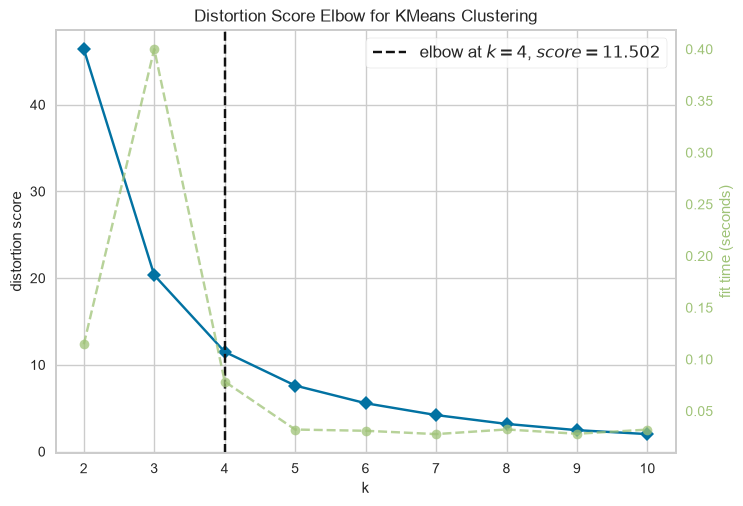

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [32]:
visualizer = KElbowVisualizer(model, k=(2, 11), force_model=True)
visualizer.fit(X_scaled)
visualizer.show()

### Untuk Advanced

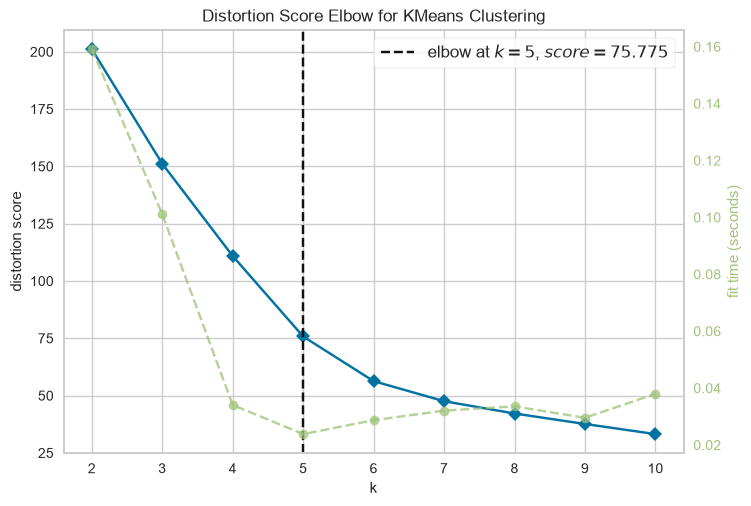

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [33]:
visualizer = KElbowVisualizer(model, k=(2, 11), force_model=True)
visualizer.fit(X_scaled_advanced)
visualizer.show()

## Melakukan K-Means Untuk Kolom Cluster (Kaggle Stores)
Pada bagian ini, dilakukan eksperimen clustering toko untuk menguji apakah kolom `cluster` (17 cluster) pada `stores.csv` dapat direkonstruksi menggunakan profil bauran penjualan produk (*Product Mix / Family Sales Proportions*) serta metrik total penjualan dan rata-rata transaksi.

In [34]:
# 1. Menghitung Proporsi Penjualan per Kategori Produk (Product Family Proportions / Sales Mix)
fam_sales = train.groupby(['store_nbr', 'family'])['sales'].sum().unstack(fill_value=0)
fam_prop = fam_sales.div(fam_sales.sum(axis=1), axis=0)

# 2. Menghitung Total Penjualan dan Rata-rata Transaksi per Toko
tot_sales = train.groupby('store_nbr')['sales'].sum()
avg_trans = transactions.groupby('store_nbr')['transactions'].mean()

# 3. Menggabungkan Fitur Menjadi Satu DataFrame
store_cluster_features = fam_prop.copy()
store_cluster_features['total_sales'] = tot_sales
store_cluster_features['avg_transactions'] = avg_trans
store_cluster_features = store_cluster_features.reset_index().merge(stores[['store_nbr', 'type', 'cluster']], on='store_nbr')

store_cluster_features.head()


,store_nbr,AUTOMOTIVE,BABY CARE,BEAUTY,BEVERAGES,BOOKS,BREAD/BAKERY,CELEBRATION,CLEANING,DAIRY,...,PLAYERS AND ELECTRONICS,POULTRY,PREPARED FOODS,PRODUCE,SCHOOL AND OFFICE SUPPLIES,SEAFOOD,total_sales,avg_transactions,type,cluster
0,1,0.000387,0.000000,0.000287,0.189026,0.000015,0.040296,0.001187,0.076248,0.074539,...,0.000630,0.033837,0.009613,0.172734,0.000020,0.003089,1.414501e+07,1523.844272,D,13
1,2,0.000422,0.000004,0.000368,0.192691,0.000011,0.042875,0.000621,0.075420,0.066653,...,0.000445,0.038012,0.009759,0.129032,0.000036,0.002516,2.155739e+07,1920.036374,D,13
2,3,0.000310,0.000013,0.000321,0.224864,0.000011,0.038378,0.000960,0.068825,0.068081,...,0.000590,0.037741,0.012259,0.170622,0.000025,0.003545,5.048191e+07,3201.879475,D,8
3,4,0.000358,0.000001,0.000364,0.193982,0.000014,0.036113,0.000568,0.078787,0.070291,...,0.000481,0.039981,0.008880,0.139589,0.000019,0.002912,1.890970e+07,1502.987470,D,9
4,5,0.000590,0.000014,0.000557,0.162504,0.000015,0.041229,0.001679,0.106959,0.055879,...,0.000515,0.026912,0.009491,0.106050,0.000052,0.001434,1.559240e+07,1400.045915,D,4


In [35]:
# Standarisasi fitur dan pemodelan K-Means dengan K=17
feature_cols = [c for c in fam_prop.columns] + ['total_sales', 'avg_transactions']
scaler = StandardScaler()
X_scaled_cluster = scaler.fit_transform(store_cluster_features[feature_cols])

kmeans_17 = KMeans(n_clusters=17, random_state=42, n_init=20)
store_cluster_features['kmeans_cluster_17'] = kmeans_17.fit_predict(X_scaled_cluster)


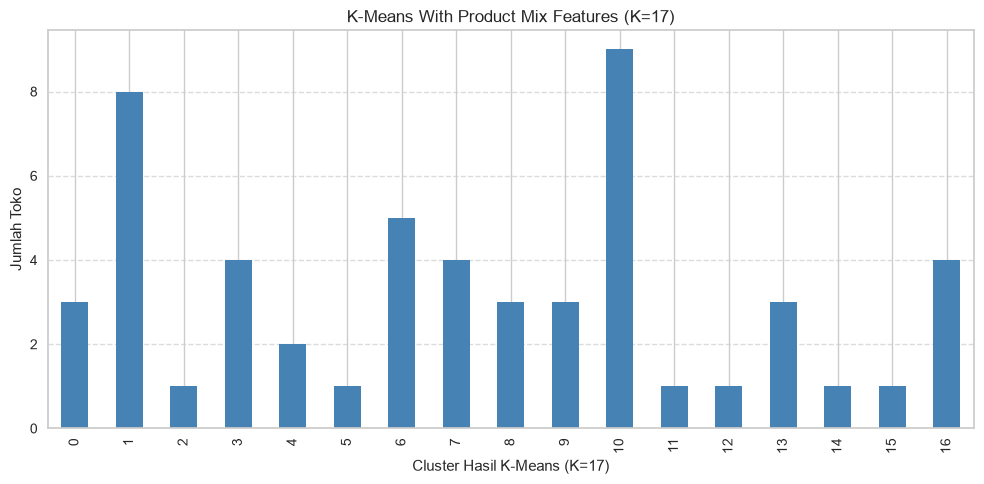

In [36]:
# Distribusi Jumlah Toko per Cluster Hasil K-Means (K=17)
plt.figure(figsize=(10, 5))
store_cluster_features['kmeans_cluster_17'].value_counts().sort_index().plot(kind='bar', title='K-Means With Product Mix Features (K=17)', color='steelblue')
plt.xlabel('Cluster Hasil K-Means (K=17)')
plt.ylabel('Jumlah Toko')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [37]:
# Evaluasi Kesesuaian Hasil K-Means (K=17) terhadap Kolom Cluster Asli Kaggle
ari_cluster = adjusted_rand_score(store_cluster_features['cluster'], store_cluster_features['kmeans_cluster_17'])
nmi_cluster = normalized_mutual_info_score(store_cluster_features['cluster'], store_cluster_features['kmeans_cluster_17'])

print(f"Adjusted Rand Index: {ari_cluster:.4f}")
print(f"Normalized Mutual Info: {nmi_cluster:.4f}")


Adjusted Rand Index: 0.2615
Normalized Mutual Info: 0.7192


In [38]:
# Matriks Kontingensi (Crosstab) antara Cluster Asli Kaggle dan Hasil K-Means K=17
pd.crosstab(store_cluster_features['cluster'], store_cluster_features['kmeans_cluster_17'])

kmeans_cluster_17,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
cluster,,,,,,,,,,,,,,,,,
1,0,2,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,3,0,0,0,0,0,3,0,0,0,1,0,0,0,0,0,0
4,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,1,0,1,0,3,0,0,0,0,0,1
7,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0
9,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


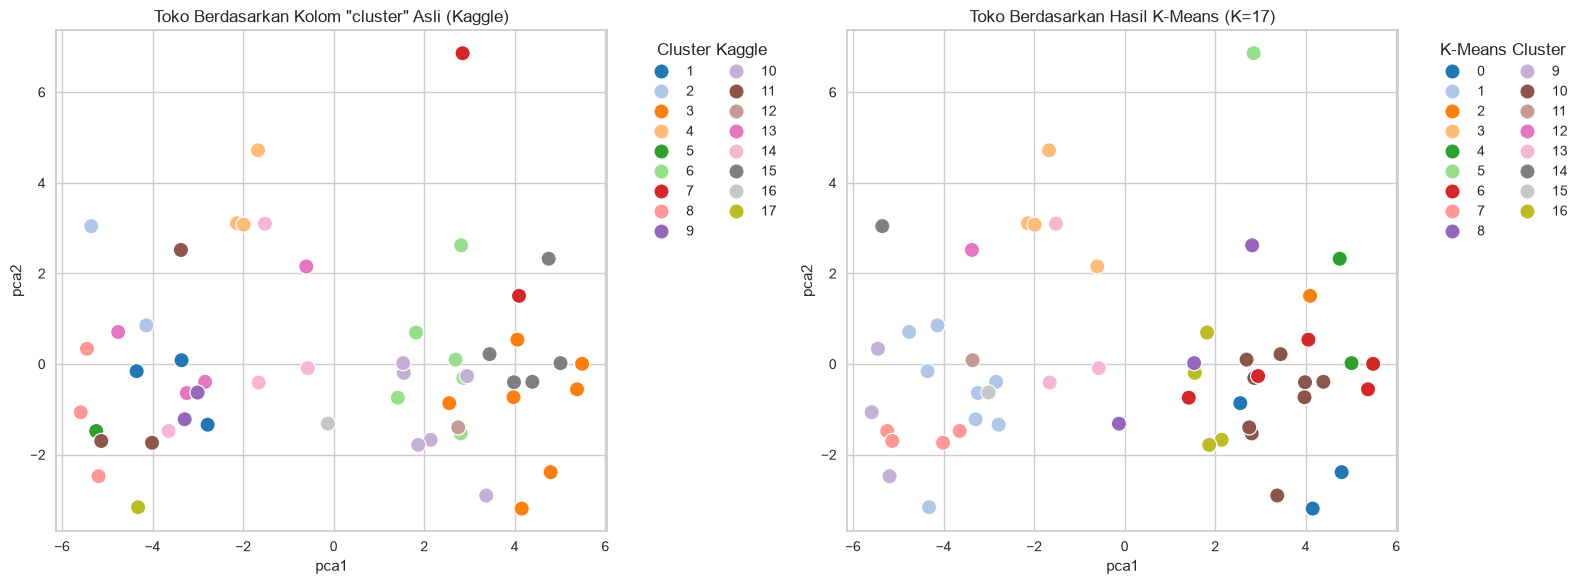

In [39]:
# Visualisasi PCA 2D: Membandingkan Cluster Asli Kaggle vs Hasil K-Means K=17
pca = PCA(n_components=2)
X_pca_cluster = pca.fit_transform(X_scaled_cluster)
store_cluster_features['pca1'], store_cluster_features['pca2'] = X_pca_cluster[:,0], X_pca_cluster[:,1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    data=store_cluster_features, x='pca1', y='pca2', 
    hue='cluster', ax=axes[0], s=120, palette='tab20', legend='full'
)
axes[0].set_title('Toko Berdasarkan Kolom "cluster" Asli (Kaggle)', fontsize=12)
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, title='Cluster Kaggle')

sns.scatterplot(
    data=store_cluster_features, x='pca1', y='pca2', 
    hue='kmeans_cluster_17', ax=axes[1], s=120, palette='tab20', legend='full'
)
axes[1].set_title('Toko Berdasarkan Hasil K-Means (K=17)', fontsize=12)
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, title='K-Means Cluster')

plt.tight_layout()
plt.show()


### Melihat Jumlah K Ideal dengan Elbow Method (Product Mix & Transaction Features)


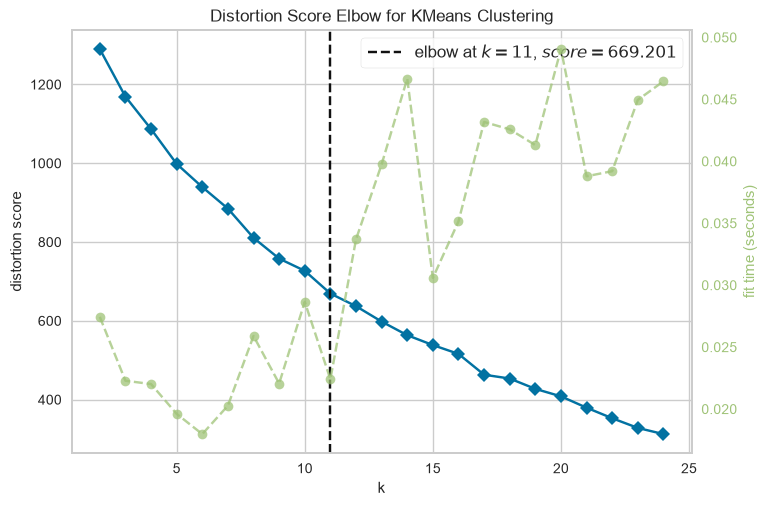

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [40]:
model_cluster_elbow = KMeans(random_state=42, n_init=10)
visualizer_cluster = KElbowVisualizer(model_cluster_elbow, k=(2, 25), force_model=True)
visualizer_cluster.fit(X_scaled_cluster)
visualizer_cluster.show()


### Kesimpulan dan Analisis Akhir
1. **Rekonstruksi Kolom `cluster`**: Dengan menggunakan fitur profil bauran penjualan (*Product Family Proportions* 33 kategori) ditambah *Total Sales* dan *Average Transactions*, nilai **NMI mencapai ~0.72 (71.9%)** terhadap kolom `cluster` di `stores.csv`. Hal ini membuktikan bahwa kolom `cluster` pada dataset asli Kaggle memang sangat kuat dipengaruhi oleh profil produk yang terjual di tiap toko serta volume transaksinya.
2. **Perbedaan Mendasar `type` vs `cluster`**:
   - `type` (5 kelompok): Merupakan format bisnis fisik toko yang ditentukan oleh korporasi ritel.
   - `cluster` (17 kelompok): Merupakan hasil segmentasi pola penjualan dan bauran produk toko (*product mix similarity*).
3. **Pemanfaatan untuk Pemodelan LSTM**: Pengelompokan toko ke dalam cluster ini dapat dimanfaatkan untuk melatih model LSTM per-cluster (*Cluster-based LSTM Forecasting*) atau dijadikan sebagai fitur kategorikal (*Cluster Embedding*) guna meningkatkan performa peramalan penjualan.